# 스마트 창고 출고 지연 예측 — Model v2 (Optuna 튜닝)

v1 대비 변경 사항:
- Optuna로 LightGBM / XGBoost / CatBoost 하이퍼파라미터 개별 최적화
- 튜닝된 파라미터로 Group K-Fold 최종 학습
- 앙상블

## 0. 라이브러리 로드

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import optuna
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED    = 42
N_FOLD  = 5
TARGET  = 'avg_delay_minutes_next_30m'
ID_COLS = ['ID', 'layout_id', 'scenario_id']

# Optuna 튜닝 설정
N_TRIALS    = 50   # 시간 여유 있으면 100으로 늘려도 됨
TUNE_FOLDS  = 3    # 튜닝 시 빠른 검증을 위해 3-Fold 사용

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## 1. 데이터 로드 및 전처리 (v1과 동일)

In [2]:
train  = pd.read_csv('./open/train.csv')
test   = pd.read_csv('./open/test.csv')
layout = pd.read_csv('./open/layout_info.csv')

# layout_info merge
train = train.merge(layout, on='layout_id', how='left')
test  = test.merge(layout, on='layout_id', how='left')

# layout_type 레이블 인코딩
le = LabelEncoder()
train['layout_type'] = le.fit_transform(train['layout_type'].astype(str))
test['layout_type']  = le.transform(test['layout_type'].astype(str))

# 시나리오 내 정렬
train = train.sort_values(['scenario_id', 'shift_hour']).reset_index(drop=True)
test  = test.sort_values(['scenario_id', 'shift_hour']).reset_index(drop=True)

print(f'train: {train.shape} / test: {test.shape}')

train: (250000, 108) / test: (50000, 107)


In [3]:
# 시계열 피처 생성
ts_features = [
    'order_inflow_15m', 'robot_utilization', 'congestion_score',
    'fault_count_15m',  'loading_dock_util', 'battery_mean',
    'blocked_path_15m', 'task_reassign_15m', 'low_battery_ratio',
    'avg_trip_distance'
]

def make_ts_features(df, cols, group_col='scenario_id'):
    df = df.copy()
    grp = df.groupby(group_col)
    for col in cols:
        for lag in [1, 2, 3]:
            df[f'{col}_lag{lag}'] = grp[col].shift(lag)
        for win in [3, 5]:
            df[f'{col}_roll_mean{win}'] = grp[col].transform(
                lambda x: x.shift(1).rolling(win, min_periods=1).mean())
            df[f'{col}_roll_std{win}'] = grp[col].transform(
                lambda x: x.shift(1).rolling(win, min_periods=2).std())
        df[f'{col}_cumsum'] = grp[col].transform(lambda x: x.shift(1).cumsum())
    return df

def make_extra_features(df):
    df = df.copy()
    df['time_step']          = df.groupby('scenario_id').cumcount()
    df['robot_active_ratio'] = df['robot_active'] / (df['robot_active'] + df['robot_idle'] + df['robot_charging'] + 1e-6)
    df['battery_congestion'] = df['low_battery_ratio'] * df['congestion_score']
    df['urgent_volume']      = df['urgent_order_ratio'] * df['order_inflow_15m']
    df['fault_impact']       = df['fault_count_15m'] * df['avg_recovery_time']
    df['dock_stress']        = df['outbound_truck_wait_min'] * df['loading_dock_util']
    return df

train = make_ts_features(train, ts_features)
test  = make_ts_features(test,  ts_features)
train = make_extra_features(train)
test  = make_extra_features(test)

feat_cols = [c for c in train.columns if c not in ID_COLS + [TARGET]]
X      = train[feat_cols]
y      = train[TARGET]
X_test = test[feat_cols]
groups = train['scenario_id']

print(f'피처 수: {len(feat_cols)}')

피처 수: 190


## 2. Optuna 공통 CV 함수

In [4]:
def optuna_cv(model_fn, X, y, groups, n_folds=TUNE_FOLDS):
    """튜닝용 경량 Group K-Fold CV — RMSE 반환"""
    gkf = GroupKFold(n_splits=n_folds)
    scores = []
    for tr_idx, val_idx in gkf.split(X, y, groups):
        X_tr, y_tr   = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        model = model_fn()
        model.fit(X_tr, y_tr)
        scores.append(rmse(y_val, model.predict(X_val)))
    return np.mean(scores)

## 3. LightGBM Optuna 튜닝

In [5]:
def lgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 500, 3000, step=100),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        max_depth         = trial.suggest_int('max_depth', 4, 10),
        num_leaves        = trial.suggest_int('num_leaves', 31, 255),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        min_child_samples = trial.suggest_int('min_child_samples', 10, 100),
        random_state      = SEED,
        verbose           = -1,
        n_jobs            = -1,
    )
    return optuna_cv(lambda: LGBMRegressor(**params), X, y, groups)

print(f'LightGBM Optuna 탐색 시작 ({N_TRIALS} trials)...')
lgb_study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
lgb_study.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

lgb_best = lgb_study.best_params
lgb_best.update({'random_state': SEED, 'verbose': -1, 'n_jobs': -1})
print(f'\nLGB Best RMSE: {lgb_study.best_value:.4f}')
print(f'LGB Best params: {lgb_best}')

LightGBM Optuna 탐색 시작 (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


LGB Best RMSE: 21.3513
LGB Best params: {'n_estimators': 700, 'learning_rate': 0.011479253721973068, 'max_depth': 7, 'num_leaves': 157, 'subsample': 0.9417089137635153, 'colsample_bytree': 0.7182509076515207, 'reg_alpha': 0.002313051327322259, 'reg_lambda': 0.007098159082336851, 'min_child_samples': 70, 'random_state': 42, 'verbose': -1, 'n_jobs': -1}


## 4. XGBoost Optuna 튜닝

In [6]:
def xgb_objective(trial):
    params = dict(
        n_estimators          = trial.suggest_int('n_estimators', 500, 3000, step=100),
        learning_rate         = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        max_depth             = trial.suggest_int('max_depth', 4, 10),
        subsample             = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree      = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha             = trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        reg_lambda            = trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        min_child_weight      = trial.suggest_int('min_child_weight', 1, 20),
        gamma                 = trial.suggest_float('gamma', 0.0, 5.0),
        random_state          = SEED,
        verbosity             = 0,
        n_jobs                = -1,
        tree_method           = 'hist',
        early_stopping_rounds = 50,
    )
    gkf = GroupKFold(n_splits=TUNE_FOLDS)
    scores = []
    for tr_idx, val_idx in gkf.split(X, y, groups):
        X_tr, y_tr   = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        model = XGBRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        scores.append(rmse(y_val, model.predict(X_val)))
    return np.mean(scores)

print(f'XGBoost Optuna 탐색 시작 ({N_TRIALS} trials)...')
xgb_study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

xgb_best = xgb_study.best_params
xgb_best.update({
    'random_state': SEED, 'verbosity': 0,
    'n_jobs': -1, 'tree_method': 'hist',
    'early_stopping_rounds': 100
})
print(f'\nXGB Best RMSE: {xgb_study.best_value:.4f}')
print(f'XGB Best params: {xgb_best}')

XGBoost Optuna 탐색 시작 (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


XGB Best RMSE: 21.3192
XGB Best params: {'n_estimators': 1700, 'learning_rate': 0.010069367505586393, 'max_depth': 8, 'subsample': 0.7701921669162993, 'colsample_bytree': 0.6281558321428306, 'reg_alpha': 0.00681854496911729, 'reg_lambda': 5.936330336429031, 'min_child_weight': 17, 'gamma': 1.217006530058639, 'random_state': 42, 'verbosity': 0, 'n_jobs': -1, 'tree_method': 'hist', 'early_stopping_rounds': 100}


## 5. CatBoost Optuna 튜닝

In [7]:
def cat_objective(trial):
    params = dict(
        iterations        = trial.suggest_int('iterations', 500, 3000, step=100),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        depth             = trial.suggest_int('depth', 4, 10),
        l2_leaf_reg       = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        random_strength   = trial.suggest_float('random_strength', 0.0, 1.0),
        border_count      = trial.suggest_int('border_count', 32, 255),
        random_seed       = SEED,
        verbose           = 0,
        early_stopping_rounds = 50,
        task_type         = 'CPU',
    )
    gkf = GroupKFold(n_splits=TUNE_FOLDS)
    scores = []
    for tr_idx, val_idx in gkf.split(X, y, groups):
        X_tr, y_tr   = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val))
        scores.append(rmse(y_val, model.predict(X_val)))
    return np.mean(scores)

print(f'CatBoost Optuna 탐색 시작 ({N_TRIALS} trials)...')
cat_study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
cat_study.optimize(cat_objective, n_trials=N_TRIALS, show_progress_bar=True)

cat_best = cat_study.best_params
cat_best.update({
    'random_seed': SEED, 'verbose': 0,
    'early_stopping_rounds': 100, 'task_type': 'CPU'
})
print(f'\nCAT Best RMSE: {cat_study.best_value:.4f}')
print(f'CAT Best params: {cat_best}')

CatBoost Optuna 탐색 시작 (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


CAT Best RMSE: 21.4168
CAT Best params: {'iterations': 2000, 'learning_rate': 0.011496997241230818, 'depth': 10, 'l2_leaf_reg': 5.1253106234016546, 'bagging_temperature': 0.04857511330881678, 'random_strength': 0.002172876360345995, 'border_count': 56, 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 100, 'task_type': 'CPU'}


## 6. 튜닝 결과 요약

Optuna 튜닝 결과 요약
LGB  Best RMSE (3-Fold): 21.3513
XGB  Best RMSE (3-Fold): 21.3192
CAT  Best RMSE (3-Fold): 21.4168


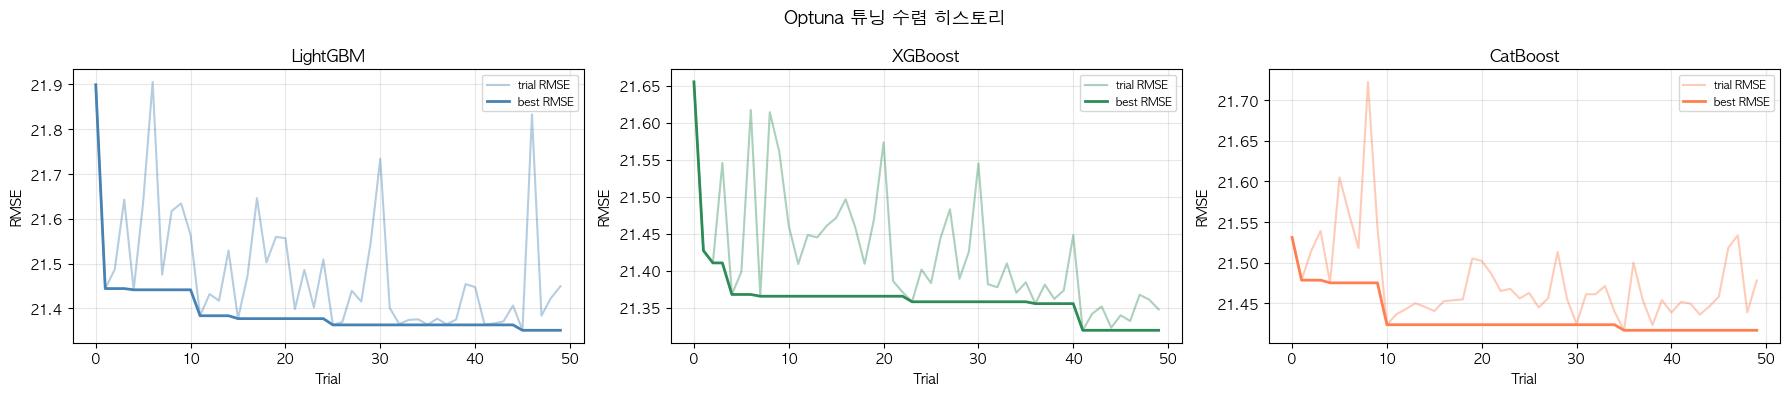

In [8]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print('=' * 50)
print('Optuna 튜닝 결과 요약')
print('=' * 50)
print(f'LGB  Best RMSE (3-Fold): {lgb_study.best_value:.4f}')
print(f'XGB  Best RMSE (3-Fold): {xgb_study.best_value:.4f}')
print(f'CAT  Best RMSE (3-Fold): {cat_study.best_value:.4f}')

# Trial 히스토리 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, study, name, color in zip(
    axes,
    [lgb_study, xgb_study, cat_study],
    ['LightGBM', 'XGBoost', 'CatBoost'],
    ['steelblue', 'seagreen', 'coral']
):
    vals = [t.value for t in study.trials if t.value is not None]
    best = [min(vals[:i+1]) for i in range(len(vals))]
    ax.plot(vals, alpha=0.4, color=color, label='trial RMSE')
    ax.plot(best, color=color, linewidth=2, label='best RMSE')
    ax.set_title(f'{name}', fontsize=12)
    ax.set_xlabel('Trial')
    ax.set_ylabel('RMSE')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Optuna 튜닝 수렴 히스토리', fontsize=13)
plt.tight_layout()
plt.show()

## 7. 최적 파라미터로 5-Fold 최종 학습

In [9]:
gkf5 = GroupKFold(n_splits=N_FOLD)

def run_cv_final(model_fn, model_name, fit_kwargs_fn=None):
    oof   = np.zeros(len(X))
    preds = np.zeros(len(X_test))
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(gkf5.split(X, y, groups)):
        X_tr, y_tr   = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = model_fn()
        if fit_kwargs_fn:
            model.fit(X_tr, y_tr, **fit_kwargs_fn(X_val, y_val))
        else:
            model.fit(X_tr, y_tr)

        oof[val_idx] = model.predict(X_val)
        preds += model.predict(X_test) / N_FOLD

        score = rmse(y_val, oof[val_idx])
        fold_scores.append(score)
        print(f'  [{model_name}] Fold {fold+1}  RMSE: {score:.4f}')

    total = rmse(y, oof)
    print(f'  [{model_name}] OOF RMSE: {total:.4f}\n')
    return oof, preds, total

In [10]:
print('=== LightGBM (튜닝 파라미터) ===')
lgb_oof, lgb_pred, lgb_score = run_cv_final(
    lambda: LGBMRegressor(**lgb_best),
    'LGB',
    lambda xv, yv: {
        'eval_set': [(xv, yv)],
        'callbacks': [lgb.early_stopping(100, verbose=False), lgb.log_evaluation(500)]
    }
)

=== LightGBM (튜닝 파라미터) ===
[500]	valid_0's l2: 480.809
  [LGB] Fold 1  RMSE: 21.9063
[500]	valid_0's l2: 460.431
  [LGB] Fold 2  RMSE: 21.4371
[500]	valid_0's l2: 391.488
  [LGB] Fold 3  RMSE: 19.7834
[500]	valid_0's l2: 502.988
  [LGB] Fold 4  RMSE: 22.4065
[500]	valid_0's l2: 445.94
  [LGB] Fold 5  RMSE: 21.1041
  [LGB] OOF RMSE: 21.3460



In [11]:
print('=== XGBoost (튜닝 파라미터) ===')
xgb_oof, xgb_pred, xgb_score = run_cv_final(
    lambda: XGBRegressor(**xgb_best),
    'XGB',
    lambda xv, yv: {'eval_set': [(xv, yv)], 'verbose': False}
)

=== XGBoost (튜닝 파라미터) ===
  [XGB] Fold 1  RMSE: 21.9313
  [XGB] Fold 2  RMSE: 21.3661
  [XGB] Fold 3  RMSE: 19.7305
  [XGB] Fold 4  RMSE: 22.4006
  [XGB] Fold 5  RMSE: 21.0330
  [XGB] OOF RMSE: 21.3118



In [12]:
print('=== CatBoost (튜닝 파라미터) ===')
cat_oof, cat_pred, cat_score = run_cv_final(
    lambda: CatBoostRegressor(**cat_best),
    'CAT',
    lambda xv, yv: {'eval_set': (xv, yv)}
)

=== CatBoost (튜닝 파라미터) ===
  [CAT] Fold 1  RMSE: 21.9582
  [CAT] Fold 2  RMSE: 21.4414
  [CAT] Fold 3  RMSE: 19.8121
  [CAT] Fold 4  RMSE: 22.4111
  [CAT] Fold 5  RMSE: 21.1271
  [CAT] OOF RMSE: 21.3683



## 8. 앙상블 및 v1 대비 성능 비교

In [13]:
# RMSE 역수 가중 앙상블
scores  = np.array([lgb_score, xgb_score, cat_score])
weights = (1 / scores) / (1 / scores).sum()

ens_oof  = weights[0]*lgb_oof  + weights[1]*xgb_oof  + weights[2]*cat_oof
ens_pred = weights[0]*lgb_pred + weights[1]*xgb_pred + weights[2]*cat_pred
ens_score = rmse(y, ens_oof)

simple_oof  = (lgb_oof + xgb_oof + cat_oof) / 3
simple_pred = (lgb_pred + xgb_pred + cat_pred) / 3
simple_score = rmse(y, simple_oof)

print(f'LGB   RMSE: {lgb_score:.4f}  가중치: {weights[0]:.4f}')
print(f'XGB   RMSE: {xgb_score:.4f}  가중치: {weights[1]:.4f}')
print(f'CAT   RMSE: {cat_score:.4f}  가중치: {weights[2]:.4f}')
print(f'\n앙상블(가중) OOF RMSE : {ens_score:.4f}')
print(f'앙상블(단순) OOF RMSE : {simple_score:.4f}')
print(f'\nv1 앙상블 대비 개선   : {21.3531 - min(ens_score, simple_score):+.4f}')

LGB   RMSE: 21.3460  가중치: 0.3333
XGB   RMSE: 21.3118  가중치: 0.3338
CAT   RMSE: 21.3683  가중치: 0.3329

앙상블(가중) OOF RMSE : 21.2717
앙상블(단순) OOF RMSE : 21.2717

v1 앙상블 대비 개선   : +0.0814


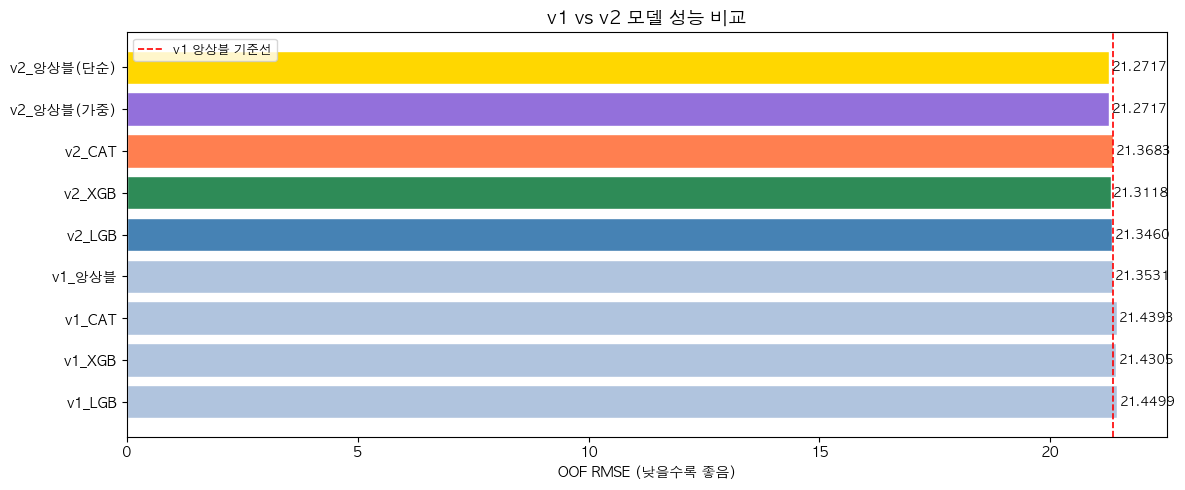

In [14]:
# 성능 비교 시각화
model_names  = ['v1_LGB', 'v1_XGB', 'v1_CAT', 'v1_앙상블',
                'v2_LGB', 'v2_XGB', 'v2_CAT', 'v2_앙상블(가중)', 'v2_앙상블(단순)']
model_scores = [21.4499, 21.4305, 21.4393, 21.3531,
                lgb_score, xgb_score, cat_score, ens_score, simple_score]
colors = ['lightsteelblue']*4 + ['steelblue', 'seagreen', 'coral', 'mediumpurple', 'gold']

plt.figure(figsize=(12, 5))
bars = plt.barh(model_names, model_scores, color=colors, edgecolor='white')
for bar, score in zip(bars, model_scores):
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{score:.4f}', va='center', fontsize=9)
plt.axvline(21.3531, color='red', linestyle='--', linewidth=1.2, label='v1 앙상블 기준선')
plt.xlabel('OOF RMSE (낮을수록 좋음)')
plt.title('v1 vs v2 모델 성능 비교', fontsize=13)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 9. 제출 파일 생성

In [15]:
best_score = min(ens_score, simple_score)
best_pred  = ens_pred if ens_score <= simple_score else simple_pred
best_label = '가중앙상블' if ens_score <= simple_score else '단순평균'
print(f'선택된 앙상블: {best_label}  (RMSE: {best_score:.4f})')

submission = pd.read_csv('./open/sample_submission.csv')
submission[TARGET] = best_pred
submission.to_csv('./submission_v2.csv', index=False)

print(f'\nsubmission_v2.csv 저장 완료')
print(f'예측값 통계:')
print(submission[TARGET].describe().round(4))

선택된 앙상블: 단순평균  (RMSE: 21.2717)

submission_v2.csv 저장 완료
예측값 통계:
count    50000.0000
mean        23.6720
std         17.4634
min          0.6708
25%          6.7263
50%         20.1314
75%         38.0127
max        117.9927
Name: avg_delay_minutes_next_30m, dtype: float64
